# 03 — EDA: Team Rolling Features

Validates the 11 team rolling features added by `src/features/team_features.py`
before they enter the model.

### Yardage features
| Feature | Description |
|---|---|
| `off_pass_rate_L3` | 3-week rolling mean of team pass rate (lagged) |
| `off_rush_yds_L3` | 3-week rolling mean of yards per rush attempt (lagged) |
| `off_pass_yds_L3` | 3-week rolling mean of yards per pass attempt (lagged) |
| `def_rush_yds_allowed_L3` | 3-week rolling mean of rush yards allowed (lagged) |
| `def_pass_yds_allowed_L3` | 3-week rolling mean of pass yards allowed (lagged) |

### EPA features
EPA captures down-and-distance efficiency that raw yardage cannot.
A 3-yard gain on 3rd-and-2 is worth far more EPA than 3 yards on 1st-and-10.

| Feature | Description |
|---|---|
| `off_epa_L3` | 3-week rolling mean EPA per play — overall offense quality |
| `off_rush_epa_L3` | 3-week rolling mean EPA on run plays |
| `off_pass_epa_L3` | 3-week rolling mean EPA on pass plays |
| `def_epa_L3` | 3-week rolling mean EPA allowed per play — overall defense quality |
| `def_rush_epa_L3` | 3-week rolling mean rush EPA allowed |
| `def_pass_epa_L3` | 3-week rolling mean pass EPA allowed |

**Sections**
- 6.1 Missingness audit
- 6.2 Distributions
- 6.3 EPA vs. yardage: complementarity check
- 6.4 Correlation with target
- 6.5 Leakage sanity check
- 6.6 Team trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

FEAT_PATH = "../data/processed/pbp_features.parquet"

YDS_COLS = [
    "off_pass_rate_L3",
    "off_rush_yds_L3",
    "off_pass_yds_L3",
    "def_rush_yds_allowed_L3",
    "def_pass_yds_allowed_L3",
]
EPA_COLS = [
    "off_epa_L3",
    "off_rush_epa_L3",
    "off_pass_epa_L3",
    "def_epa_L3",
    "def_rush_epa_L3",
    "def_pass_epa_L3",
]
TEAM_COLS = YDS_COLS + EPA_COLS

df = pd.read_parquet(FEAT_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (279917, 44)
Columns: ['game_id', 'play_id', 'season', 'week', 'game_date', 'season_type', 'home_team', 'away_team', 'posteam', 'defteam', 'posteam_type', 'game_half', 'qtr', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'down', 'ydstogo', 'yardline_100', 'posteam_score', 'defteam_score', 'play_type', 'offense_formation', 'defenders_in_box', 'number_of_pass_rushers', 'offense_personnel', 'defense_personnel', 'roof', 'surface', 'temp', 'wind', 'epa', 'yards_gained', 'off_pass_rate_L3', 'off_rush_yds_L3', 'off_pass_yds_L3', 'off_epa_L3', 'off_rush_epa_L3', 'off_pass_epa_L3', 'def_rush_yds_allowed_L3', 'def_pass_yds_allowed_L3', 'def_epa_L3', 'def_rush_epa_L3', 'def_pass_epa_L3']


---
## 6.1 Missingness Audit

In [2]:
null_pct    = df[TEAM_COLS].isna().mean().mul(100).rename("overall_null_%")
w1_null     = df[df["week"] == 1][TEAM_COLS].isna().mean().mul(100).rename("week_1_null_%")
wgt1_null   = df[df["week"] > 1][TEAM_COLS].isna().mean().mul(100).rename("week_gt1_null_%")

audit = pd.concat([null_pct, w1_null, wgt1_null], axis=1)
print(audit.to_string())

                         overall_null_%  week_1_null_%  week_gt1_null_%
off_pass_rate_L3                5.77707          100.0              0.0
off_rush_yds_L3                 5.77707          100.0              0.0
off_pass_yds_L3                 5.77707          100.0              0.0
def_rush_yds_allowed_L3         5.77707          100.0              0.0
def_pass_yds_allowed_L3         5.77707          100.0              0.0
off_epa_L3                      5.77707          100.0              0.0
off_rush_epa_L3                 5.77707          100.0              0.0
off_pass_epa_L3                 5.77707          100.0              0.0
def_epa_L3                      5.77707          100.0              0.0
def_rush_epa_L3                 5.77707          100.0              0.0
def_pass_epa_L3                 5.77707          100.0              0.0


In [3]:
assert df[df["week"] > 1][TEAM_COLS].isna().max().max() == 0.0, "Unexpected nulls in week > 1"
print("✅ All 11 team features are 0% null for week > 1")

assert df[df["week"] == 1][TEAM_COLS].isna().min().min() == 1.0, "Expected 100% null on week 1"
print("✅ Week 1 of each season is 100% NaN (expected — no prior games to roll over)")

✅ All 11 team features are 0% null for week > 1
✅ Week 1 of each season is 100% NaN (expected — no prior games to roll over)


---
## 6.2 Distributions

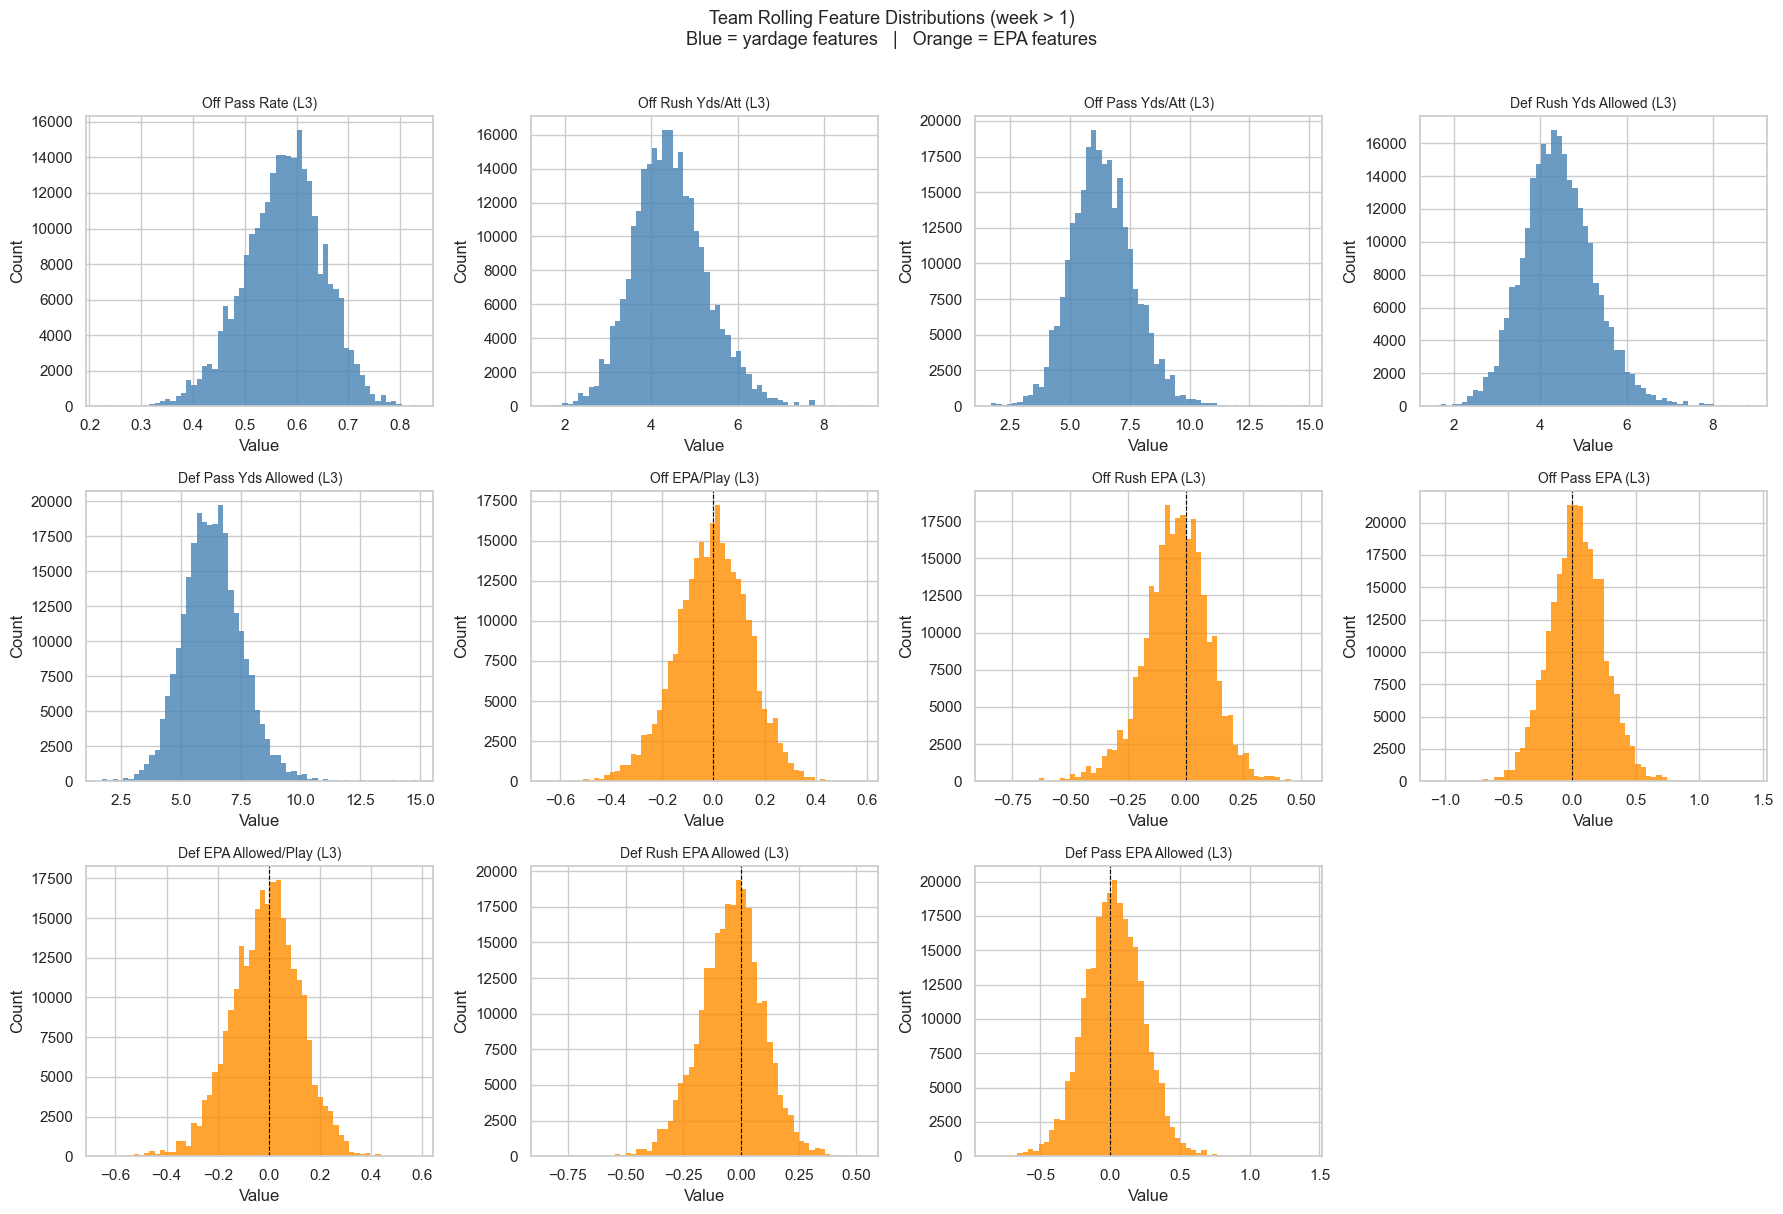

In [4]:
df_plot = df[df["week"] > 1].copy()

labels = {
    "off_pass_rate_L3":        "Off Pass Rate (L3)",
    "off_rush_yds_L3":         "Off Rush Yds/Att (L3)",
    "off_pass_yds_L3":         "Off Pass Yds/Att (L3)",
    "def_rush_yds_allowed_L3": "Def Rush Yds Allowed (L3)",
    "def_pass_yds_allowed_L3": "Def Pass Yds Allowed (L3)",
    "off_epa_L3":              "Off EPA/Play (L3)",
    "off_rush_epa_L3":         "Off Rush EPA (L3)",
    "off_pass_epa_L3":         "Off Pass EPA (L3)",
    "def_epa_L3":              "Def EPA Allowed/Play (L3)",
    "def_rush_epa_L3":         "Def Rush EPA Allowed (L3)",
    "def_pass_epa_L3":         "Def Pass EPA Allowed (L3)",
}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(labels.items()):
    ax = axes[i]
    color = "steelblue" if col in YDS_COLS else "darkorange"
    ax.hist(df_plot[col].dropna(), bins=60, color=color, edgecolor="none", alpha=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    if "epa" in col:
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

for j in range(len(labels), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Team Rolling Feature Distributions (week > 1)\n"
    "Blue = yardage features   |   Orange = EPA features",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

In [5]:
df_plot[TEAM_COLS].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
off_pass_rate_L3,263746.0,0.575,0.076,0.224,0.526,0.579,0.627,0.833
off_rush_yds_L3,263746.0,4.447,0.859,1.579,3.862,4.391,4.965,8.882
off_pass_yds_L3,263746.0,6.372,1.329,1.703,5.482,6.291,7.191,14.893
def_rush_yds_allowed_L3,263746.0,4.431,0.836,1.579,3.874,4.387,4.943,8.882
def_pass_yds_allowed_L3,263746.0,6.324,1.256,1.703,5.494,6.281,7.087,14.893
off_epa_L3,263746.0,-0.004,0.139,-0.652,-0.096,-0.000,0.091,0.581
off_rush_epa_L3,263746.0,-0.038,0.141,-0.841,-0.123,-0.032,0.054,0.524
off_pass_epa_L3,263746.0,0.038,0.217,-1.072,-0.104,0.037,0.182,1.407
def_epa_L3,263746.0,-0.012,0.133,-0.652,-0.099,-0.006,0.079,0.581
def_rush_epa_L3,263746.0,-0.042,0.138,-0.841,-0.129,-0.036,0.046,0.524


---
## 6.3 EPA vs. Yardage: Complementarity Check

EPA and yardage features are correlated but not redundant.
A high yardage average on passing plays does not guarantee high pass EPA
if those yards are achieved on easy 1st downs rather than meaningful conversions.
We expect moderate correlation (~0.6–0.8) — high enough to be measuring
the same underlying thing, low enough that both add information.

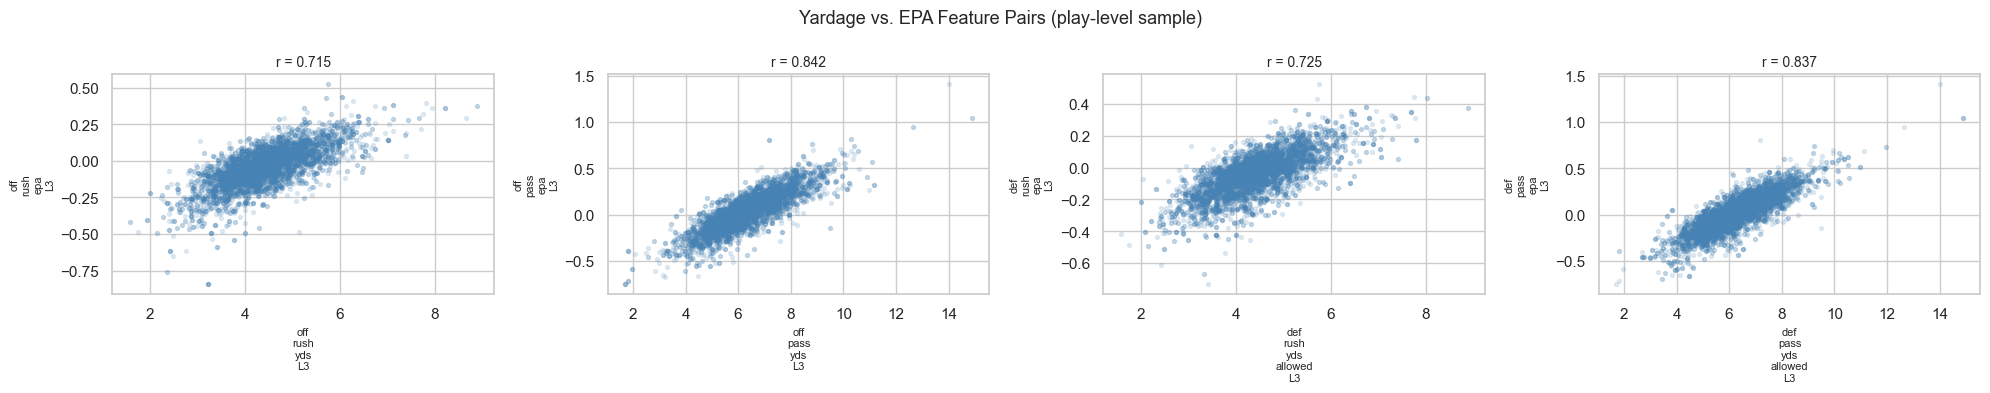

In [6]:
pairs = [
    ("off_rush_yds_L3", "off_rush_epa_L3"),
    ("off_pass_yds_L3", "off_pass_epa_L3"),
    ("def_rush_yds_allowed_L3", "def_rush_epa_L3"),
    ("def_pass_yds_allowed_L3", "def_pass_epa_L3"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (yds_col, epa_col) in zip(axes, pairs):
    sub = df_plot[[yds_col, epa_col]].dropna().sample(min(5000, len(df_plot)), random_state=42)
    r = sub.corr().iloc[0, 1]
    ax.scatter(sub[yds_col], sub[epa_col], alpha=0.15, s=8, color="steelblue")
    ax.set_xlabel(yds_col.replace("_", "\n"), fontsize=8)
    ax.set_ylabel(epa_col.replace("_", "\n"), fontsize=8)
    ax.set_title(f"r = {r:.3f}", fontsize=10)

fig.suptitle("Yardage vs. EPA Feature Pairs (play-level sample)", fontsize=13)
plt.tight_layout()
plt.show()

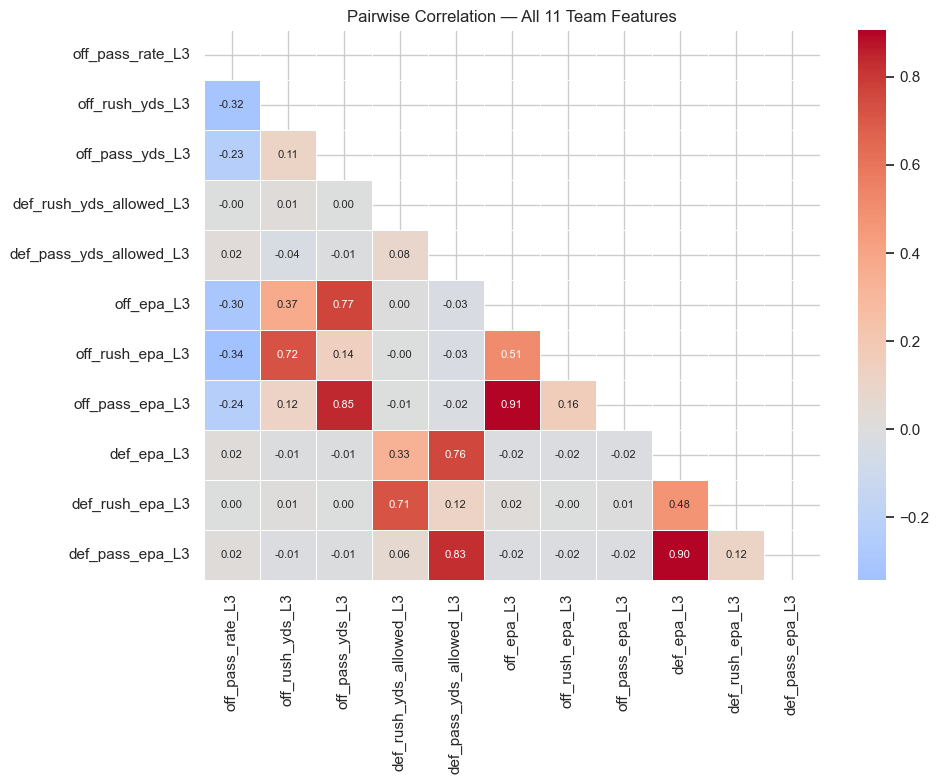

In [7]:
# Full pairwise correlation among all 11 team features
corr = df_plot[TEAM_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    linewidths=0.4, annot_kws={"size": 8}
)
ax.set_title("Pairwise Correlation — All 11 Team Features", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6.4 Correlation with Target

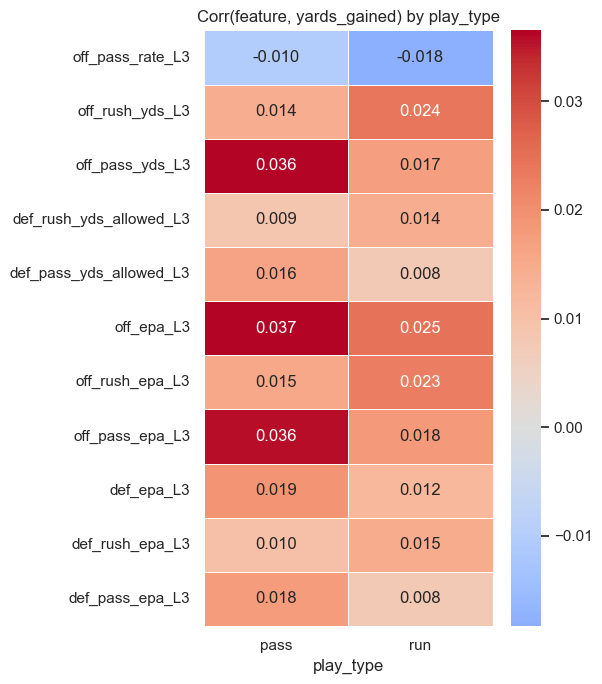

In [8]:
# Correlation of each feature with yards_gained, split by play type
results = []
for col in TEAM_COLS:
    for pt in ["run", "pass"]:
        sub = df_plot[df_plot["play_type"] == pt][[col, "yards_gained"]].dropna()
        r = sub.corr().iloc[0, 1]
        results.append({"feature": col, "play_type": pt, "corr_with_yards_gained": r})

corr_tbl = pd.DataFrame(results).pivot(index="feature", columns="play_type", values="corr_with_yards_gained")
corr_tbl = corr_tbl.loc[TEAM_COLS]  # preserve order

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    corr_tbl, annot=True, fmt=".3f", cmap="coolwarm",
    center=0, ax=ax, linewidths=0.4
)
ax.set_title("Corr(feature, yards_gained) by play_type", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

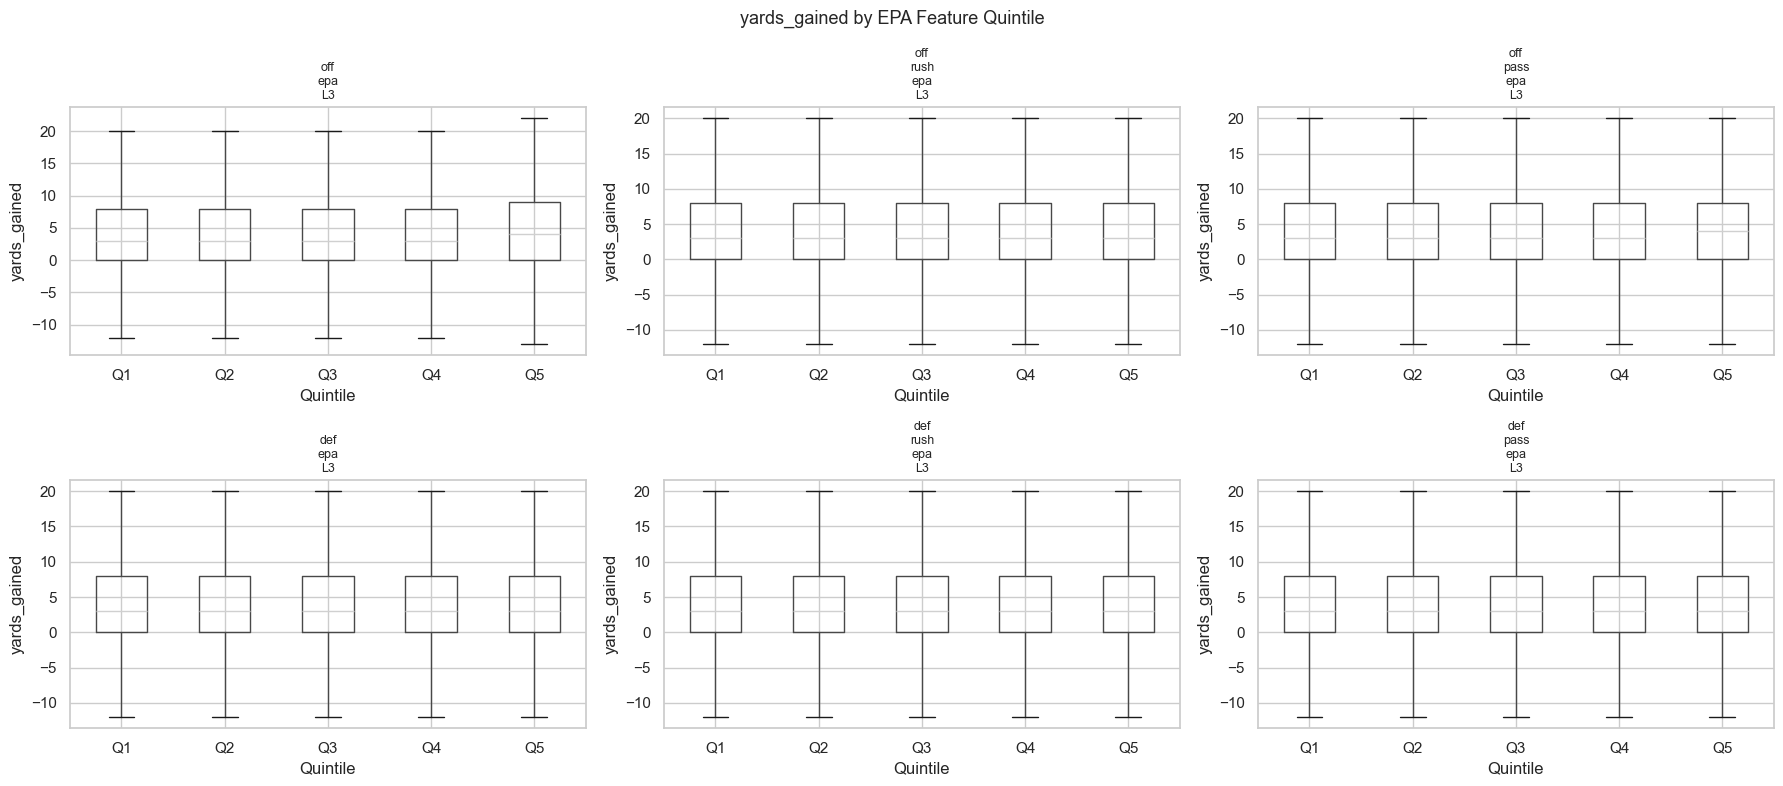

In [9]:
# Box plots: yards_gained by quintile for EPA features (week > 1 only)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, EPA_COLS):
    sub = df_plot[[col, "yards_gained"]].dropna()
    sub["quintile"] = pd.qcut(sub[col], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    sub.boxplot(column="yards_gained", by="quintile", ax=ax, showfliers=False)
    ax.set_title(col.replace("_", "\n"), fontsize=9)
    ax.set_xlabel("Quintile")
    ax.set_ylabel("yards_gained")

plt.suptitle("yards_gained by EPA Feature Quintile", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6.5 Leakage Sanity Check

For a sample team-season, show the raw weekly EPA alongside the lagged L3 value.
Confirm week N's feature only reflects weeks 1…N-1.

In [10]:
SAMPLE_TEAM   = "KC"
SAMPLE_SEASON = 2023

sample = df[
    (df["posteam"] == SAMPLE_TEAM) & (df["season"] == SAMPLE_SEASON)
].copy()

# Raw weekly EPA for the offense
weekly_raw = (
    sample.groupby("week")["epa"]
    .mean()
    .rename("raw_epa")
    .reset_index()
)

# L3 feature stored in the dataset
weekly_feat = (
    sample.groupby("week")["off_epa_L3"]
    .first()
    .rename("off_epa_L3")
    .reset_index()
)

check = weekly_raw.merge(weekly_feat, on="week")
check["expected_L3"] = (
    check["raw_epa"]
    .shift(1)
    .rolling(3, min_periods=1)
    .mean()
)

print(f"{SAMPLE_TEAM} {SAMPLE_SEASON} — raw EPA vs stored L3 vs expected L3:")
print(check.to_string(index=False, float_format="{:.4f}".format))

KC 2023 — raw EPA vs stored L3 vs expected L3:
 week  raw_epa  off_epa_L3  expected_L3
    1  -0.1457         NaN          NaN
    2   0.0464     -0.1457      -0.1457
    3   0.1965     -0.0497      -0.0497
    4   0.0798      0.0324       0.0324
    5   0.1719      0.1076       0.1076
    6  -0.0755      0.1494       0.1494
    7   0.2484      0.0588       0.0588
    8  -0.3173      0.1150       0.1150
    9   0.0173     -0.0481      -0.0481
   11  -0.1319     -0.0172      -0.0172
   12   0.2008     -0.1440      -0.1440
   13   0.1891      0.0287       0.0287
   14  -0.0571      0.0860       0.0860
   15  -0.1027      0.1109       0.1109
   16  -0.2506      0.0098       0.0098
   17   0.0182     -0.1368      -0.1368
   18  -0.1705     -0.1117      -0.1117
   19   0.0509     -0.1343      -0.1343
   20   0.2241     -0.0338      -0.0338
   21  -0.0150      0.0348       0.0348
   22  -0.0186      0.0866       0.0866


In [11]:
valid = check.dropna(subset=["off_epa_L3", "expected_L3"])
assert np.allclose(valid["off_epa_L3"], valid["expected_L3"], atol=1e-4), \
    "off_epa_L3 does not match expected shift-then-roll output!"
print("✅ Leakage check passed — week N EPA feature reflects only weeks 1…N-1")

✅ Leakage check passed — week N EPA feature reflects only weeks 1…N-1


---
## 6.6 Team Trends

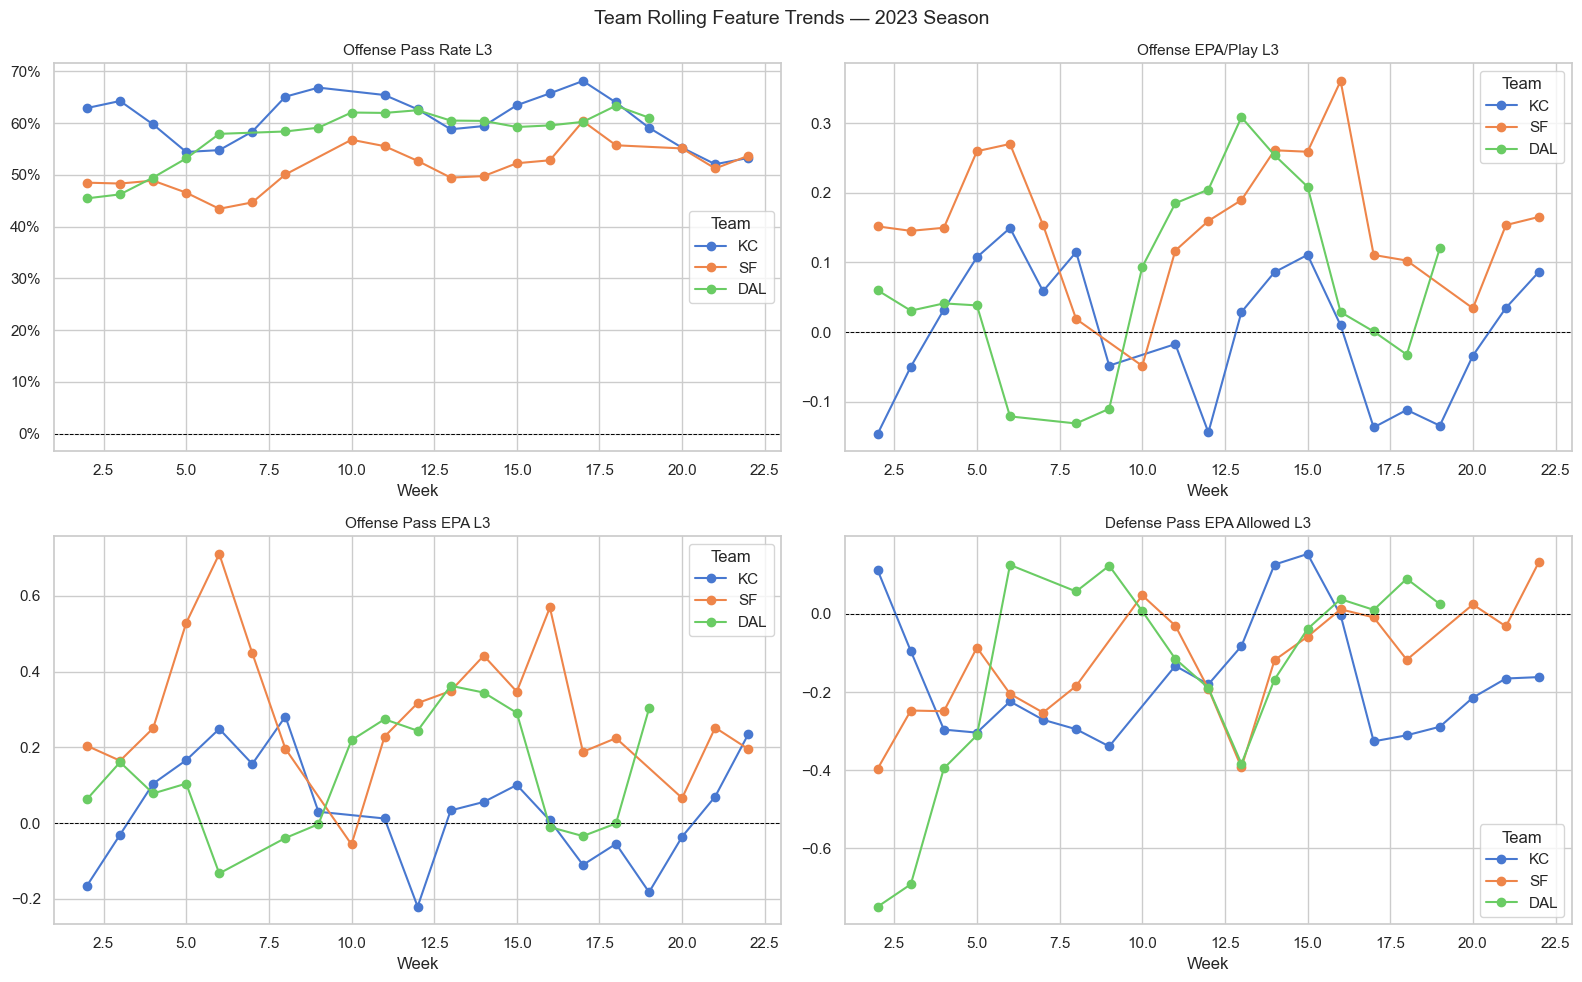

In [12]:
EXAMPLE_TEAMS = ["KC", "SF", "DAL"]
TREND_SEASON  = 2023

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def plot_trend(ax, col, title, team_key="posteam", fmt=None):
    for team in EXAMPLE_TEAMS:
        series = (
            df[(df[team_key] == team) & (df["season"] == TREND_SEASON)]
            .groupby("week")[col]
            .first()
            .reset_index()
        )
        ax.plot(series["week"], series[col], marker="o", label=team)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Week")
    ax.legend(title="Team")
    if fmt:
        ax.yaxis.set_major_formatter(fmt)

plot_trend(axes[0, 0], "off_pass_rate_L3",  "Offense Pass Rate L3",
           fmt=mtick.PercentFormatter(xmax=1.0, decimals=0))
plot_trend(axes[0, 1], "off_epa_L3",         "Offense EPA/Play L3")
plot_trend(axes[1, 0], "off_pass_epa_L3",    "Offense Pass EPA L3")
plot_trend(axes[1, 1], "def_pass_epa_L3",    "Defense Pass EPA Allowed L3",
           team_key="defteam")

fig.suptitle(f"Team Rolling Feature Trends — {TREND_SEASON} Season", fontsize=14)
plt.tight_layout()
plt.show()

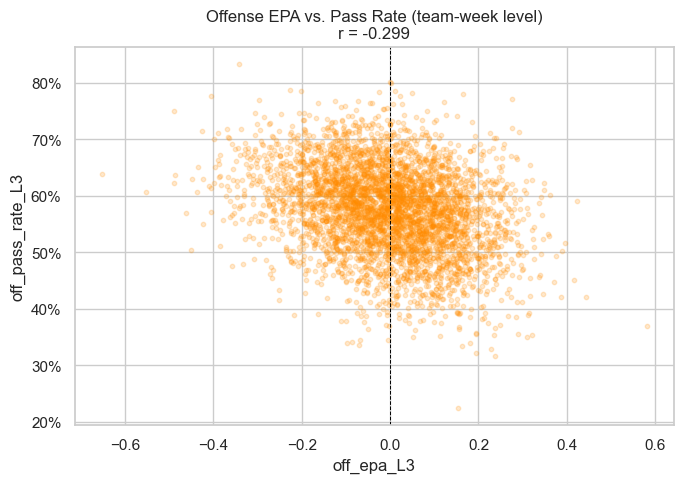

In [13]:
# EPA vs. pass rate scatter: do high-EPA offenses pass more?
weekly_agg = (
    df[df["week"] > 1]
    .groupby(["posteam", "season", "week"])[["off_epa_L3", "off_pass_rate_L3"]]
    .first()
    .dropna()
    .reset_index()
)

r = weekly_agg[["off_epa_L3", "off_pass_rate_L3"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(weekly_agg["off_epa_L3"], weekly_agg["off_pass_rate_L3"],
           alpha=0.2, s=10, color="darkorange")
ax.set_xlabel("off_epa_L3")
ax.set_ylabel("off_pass_rate_L3")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.axvline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_title(f"Offense EPA vs. Pass Rate (team-week level)\nr = {r:.3f}", fontsize=12)
plt.tight_layout()
plt.show()